# [PyBroMo](http://opensmfs.github.io/PyBroMo/) - 1. Simulate 3D trajectories - single core

<small><i>
This notebook is part of <a href="http://opensmfs.github.io/PyBroMo" target="_blank">PyBroMo</a> a 
python-based single-molecule Brownian motion diffusion simulator 
that simulates confocal smFRET
experiments.
</i></small>

## *Overview*

*In this notebook we show how to perform a 3-D trajectories simulation of a set of freely diffusing molecules. The simulation computes (and saves!) 3-D trajectories and emission rates due to a confocal excitation PSF for each single molecule. Depending on the simulation length, the required disk space can be significant (~ 750MB per minute of simulated diffusion).*

*For more info see [PyBroMo Homepage](http://opensmfs.github.io/PyBroMo/)*.

## Simulation setup

Together with a few standard python libraries we import **PyBroMo** using the short name `pbm`. 
All **PyBroMo** functions will be available as `pbm.`*something*.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import tables

import pybromo as pbm

print("Numpy version:", np.__version__)
print("PyTables version:", tables.__version__)
print("PyBroMo version:", pbm.__version__)

Numpy version: 2.5.1
PyTables version: 3.11.1
PyBroMo version: 0+untagged.386.gf82583a.dirty


Then we define the simulation parameters:

In [2]:
# Initialize the random state
rs = np.random.RandomState(seed=1)
print("Initial random state:", pbm.hashfunc(rs.get_state()))

# Simulation time step (seconds)
t_step = 0.5e-6

# Time duration of the simulation (seconds)
t_max = 1

# Diffusion coefficient
Du = 12.0  # um^2 / s
D1 = Du * (1e-6) ** 2  # m^2 / s
D2 = D1 / 2

# Simulation box definition
box = pbm.Box(x1=-4.0e-6, x2=4.0e-6, y1=-4.0e-6, y2=4.0e-6, z1=-6e-6, z2=6e-6)

# Particles definition
P = pbm.Particles.from_specs(num_particles=(3, 1), D=(D1, D2), box=box, rs=rs)

# PSF definition
psf = pbm.NumericPSF()
# psf = pbm.GaussianPSF(sx=0.2e-6, sy=0.2e-6, sz=0.8e-6)

# Particle simulation definition
S = pbm.ParticlesSimulation(t_step=t_step, t_max=t_max, particles=P, box=box, psf=psf)

print("Current random state:", pbm.hashfunc(rs.get_state()))

Initial random state: bfb867eb5c5858e04685b790d6370c458b9747d6
Current random state: ebb3a449a85a4547d8b2b17f387ee062c9a35abc


The most important line is the last line which creates an object `S` 
that contains all the simulation parameters (it also contains methods to run 
the simulation). You can print `S` and check the current parameters:

In [3]:
S

Box: X 8.0um, Y 8.0um, Z 12.0um
#Particles: 3 D: 1.2e-11, #Particles: 1 D: 6e-12, 8.6 pM, t_step 0.5us, t_max 1.0s ID_EID 0 0

Other useful simulation info:

In [4]:
S.compact_name()

'f637fc_P3_D1.2e-11_P1_D6e-12_8pM_step0.5us_t_max1.0s_ID0-0'

In [5]:
S.psf.hash()

'48e9058b57048db69147d0d395e98bde'

In [6]:
S.psf

In [7]:
S.particles.diffusion_coeff_counts

[(np.float64(1.2e-11), 3), (np.float64(6e-12), 1)]

Arrays sizes:

In [8]:
S.print_sizes()

  Number of particles: 4
  Number of time steps: 2000000
  Emission array - 1 particle (float32): 7.6 MB
  Emission array (float32): 30.5 MB
  Position array (float32): 91.6 MB 


> **NOTE:** This is the maximum in-memory array size when using a single chunk. 
> In the following, we simulate the diffusion in smaller time windows (chunks), 
> thus requiring only a few tens MB of RAM, regardless of the simulated duration.

## Brownian motion simulation

In the brownian motion simulation we keep using the same random state object `rs`. 
Initial and final state are saved so the same simulation can be reproduced. 
See [PyBroMo - A1. Reference - Data format and internals.ipynb](PyBroMo - A1. Reference - Data format and internals.ipynb) 
for more info on the random state.

In [9]:
print("Current random state:", pbm.hashfunc(rs.get_state()))

Current random state: ebb3a449a85a4547d8b2b17f387ee062c9a35abc


In [10]:
S.simulate_diffusion(total_emission=False, save_pos=True, verbose=True, rs=rs, chunksize=2**19, chunkslice="times")

- Start trajectories simulation - Tue Jul 28 16:00:27 2026
[PID 8420] Diffusion time: 1s
- End trajectories simulation - Tue Jul 28 16:00:30 2026


In [11]:
print("Current random state:", pbm.hashfunc(rs.get_state()))

Current random state: ef6cb90987c38d0982b95d9f76a14c990ad5461e


The normalized emission rate (peaks at 1) for each particle is stored 
in a 2D pytable array and accessible through the `emission` attribute:

In [12]:
print("Simulation file size: %d MB" % (S.store.h5file.get_filesize() / 1024.0 / 1024.0))

Simulation file size: 83 MB


In [13]:
S.compact_name()

'f637fc_P3_D1.2e-11_P1_D6e-12_8pM_step0.5us_t_max1.0s_ID0-0'

In [14]:
S.store.close()

# Load trajectories

In [15]:
S.compact_name()

'f637fc_P3_D1.2e-11_P1_D6e-12_8pM_step0.5us_t_max1.0s_ID0-0'

In [16]:
S = pbm.ParticlesSimulation.from_datafile(S.hash()[:4])  # Read-only by default

In [17]:
S.psf_pytables.attrs

/psf/default_psf._v_attrs (AttributeSet), 9 attributes:
   [CLASS := np.str_('ARRAY'),
    FLAVOR := np.str_('numpy'),
    TITLE := np.str_('PSF x-z slice (PSFLab array)'),
    VERSION := np.str_('2.4'),
    dir_ := WindowsPath('E:/Repos/PyBroMo/pybromo/psf_data'),
    fname := np.str_('xz_realistic_z50_150_160_580nm_n1335_HR2'),
    kind := np.str_('numeric'),
    x_step := np.float64(0.0625),
    z_step := np.float64(0.0625)]

In [18]:
S

Box: X 8.0um, Y 8.0um, Z 12.0um
#Particles: 3 D: 1.2e-11, #Particles: 1 D: 6e-12, 8.6 pM, t_step 0.5us, t_max 1.0s ID_EID 0 0

In [19]:
S.compact_name()

'f637fc_P3_D1.2e-11_P1_D6e-12_8pM_step0.5us_t_max1.0s_ID0-0'

> **BUG**: hash changed with GaussianPSF!

## Plotting the emission

This are basic debug plots. For more advanged interactive 
exploration of trajectory and emission arrays see the next notebook:

- [PyBroMo - GUI Trajectory explorer](PyBroMo - GUI Trajectory explorer.ipynb)

In [20]:
def plot_emission(S, s=0, size=2e6, slice_=None, em_th=0.01, save=False, figsize=(9, 4.5)) -> None:
    if slice_ is None:
        slice_ = (s * size, (s + 1) * size)
    slice_ = slice(*slice_)
    em = S.emission[:, slice_]
    dec = 1 if slice_.step is None else slice_.step
    t_step = S.t_step * dec
    t = np.arange(em.shape[1]) * (t_step * 1e3)
    _fig, ax = plt.subplots(figsize=figsize)
    for ip, em_ip in enumerate(em):
        if em_ip.max() < em_th:
            continue
        plt.plot(t, em_ip, label="P%d" % ip)
    ax.set_xlabel("Time (ms)")

    rs_hash = pbm.hashfunc(S.traj_group._v_attrs["init_random_state"])[:3]
    ax.set_title("%ds ID-EID: %d-%d, sim rs = %s, part rs = %s" % (s, S.ID, S.EID, rs_hash, S.particles.rs_hash[:3]))
    ax.legend(bbox_to_anchor=(1.03, 1), loc=2, borderaxespad=0.0)
    if save:
        plt.savefig("em %ds ID-EID %d-%d, rs=%s" % (s, S.ID, S.EID, rs_hash), dpi=200, bbox_inches="tight")
    # plt.close(fig)
    # display(fig)
    # fig.clear()

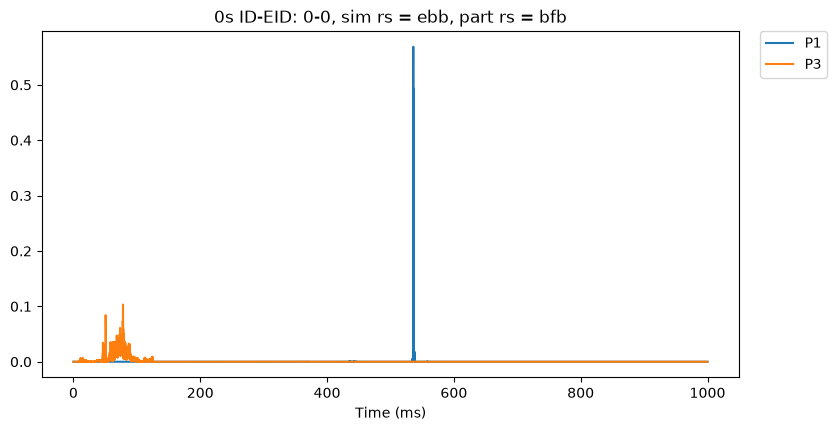

In [21]:
plot_emission(S, slice_=(0, 2e6, 10), em_th=0.05)

In [22]:
def plot_tracks_r(S, slice_=None, particles=None) -> None:
    if slice_ is None:
        slice_ = (0, 100e3, 100)
    duration = (slice_[1] - slice_[0]) * S.t_step
    slice_ = slice(*slice_)
    em = S.emission[:, slice_]
    t = np.arange(em.shape[1]) * (S.t_step * 1e3)

    if particles is None:
        particles = range(S.num_particles)

    _fig, ax = plt.subplots(1, 1, figsize=(11, 5), sharey=True)
    plt.subplots_adjust(left=0.05, right=0.93, top=0.95, bottom=0.09, wspace=0.05)
    plt.suptitle(f"Total: {S.t_step * S.n_samples:.1f} s, Visualized: {duration * 1e3:.2f} ms")

    for ip in particles:
        x, y, z = S.position[ip, :, slice_]
        r = np.sqrt(x**2 + y**2 + z**2) * 1e6
        plot_kwargs = {"ls": "", "marker": "o", "mew": 0, "ms": 4, "alpha": 0.8, "label": "P%d" % ip}
        ax.plot(t, r, **plot_kwargs)

    ax.set_ylabel("r (um)")
    ax.legend(bbox_to_anchor=(1.01, 1), loc=2, borderaxespad=0.0)
    ax.set_ylim(0)

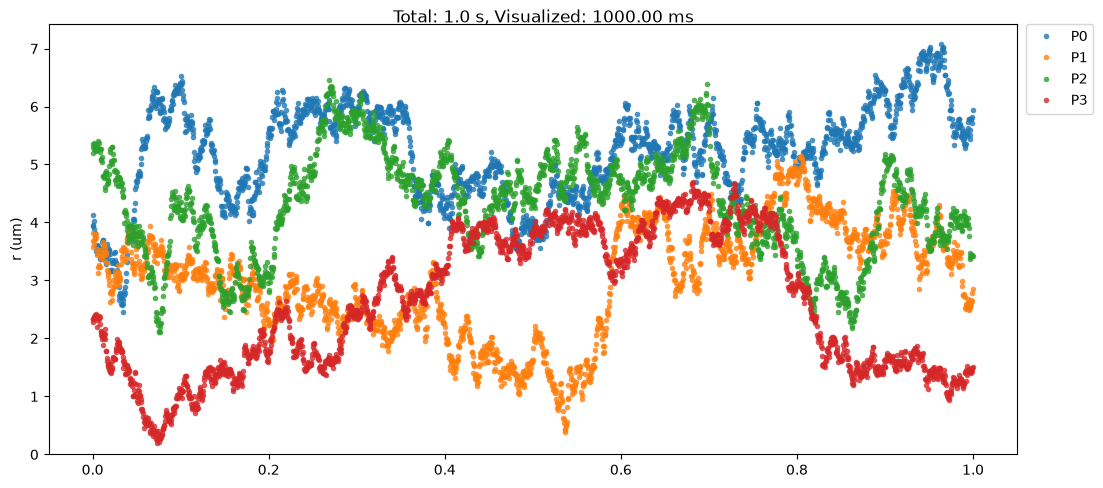

In [23]:
plot_tracks_r(S, slice_=(0, 2e6, 1000))

In [24]:
def plot_tracks(S, slice_=None, particles=None) -> None:
    if slice_ is None:
        slice_ = (0, 100e3, 100)
    duration = (slice_[1] - slice_[0]) * S.t_step
    slice_ = slice(*slice_)

    if particles is None:
        particles = range(S.num_particles)

    _fig, AX = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
    plt.subplots_adjust(left=0.05, right=0.93, top=0.95, bottom=0.09, wspace=0.05)
    plt.suptitle(f"Total: {S.t_step * S.n_samples:.1f} s, Visualized: {duration * 1e3:.2f} ms")

    for ip in particles:
        x, y, z = S.position[ip, :, slice_]
        _x0, _y0, _z0 = S.particles[ip].r0
        plot_kwargs = {"ls": "", "marker": "o", "mew": 0, "ms": 2, "alpha": 0.5, "label": "P%d" % ip}
        (l,) = AX[0].plot(x * 1e6, y * 1e6, **plot_kwargs)
        AX[1].plot(z * 1e6, y * 1e6, color=l.get_color(), **plot_kwargs)
        # AX[1].plot([x0*1e6], [y0*1e6], 'o', color=l.get_color())
        # AX[0].plot([x0*1e6], [z0*1e6], 'o', color=l.get_color())

    AX[0].set_xlabel("x (um)")
    AX[0].set_ylabel("y (um)")
    AX[1].set_xlabel("z (um)")

    sig = np.array([0.2, 0.2, 0.6]) * 1e-6
    ## Draw an outline of the PSF
    a = np.arange(360) / 360.0 * 2 * np.pi
    rx, ry, rz = sig  # draw radius at 3 sigma
    AX[0].plot((rx * np.cos(a)) * 1e6, (ry * np.sin(a)) * 1e6, lw=2, color="k")
    AX[1].plot((rz * np.cos(a)) * 1e6, (ry * np.sin(a)) * 1e6, lw=2, color="k")

    AX[0].set_xlim(-4, 4)
    AX[0].set_ylim(-4, 4)
    AX[1].set_xlim(-4, 4)

    if len(particles) <= 20:
        AX[1].legend(bbox_to_anchor=(1.01, 1), loc=2, borderaxespad=0.0)

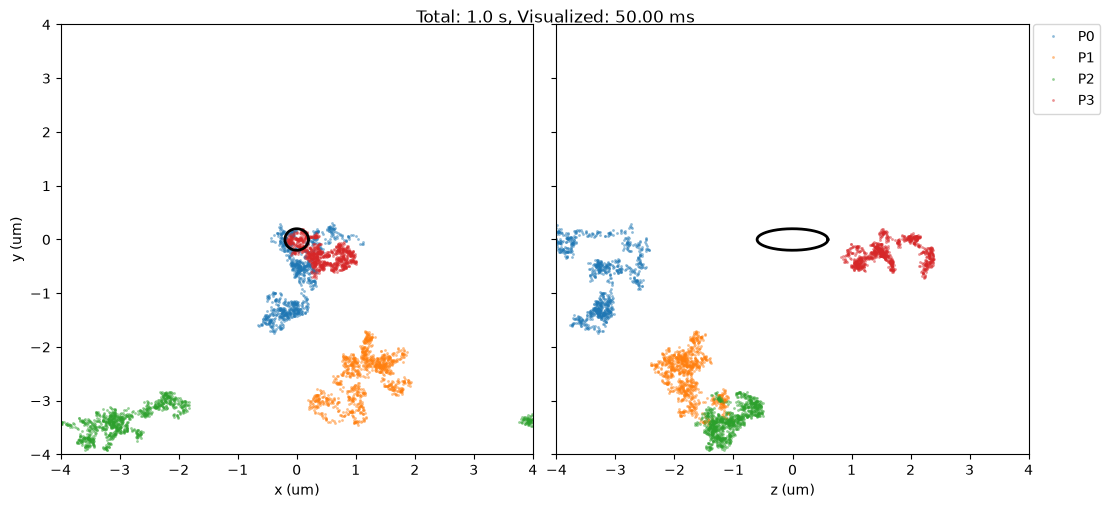

In [25]:
plot_tracks(S)  # particles=[2, 5, 7, 22, 30])

In [ ]:
# plot_tracks(S, slice_=(1.9e6, 2e6, 100), particles=[1])

In [26]:
S.store.close()

In [27]:
if hasattr(S, "ts_store"):
    S.ts_store.close()  # needed if timestamp file is already present

# Low-level timestamp simulation

Here we simulate some timestamps array one by one. To generate smFRET data in one step (donor + acceptor, single or multiple populations and create [Photon-HDF5](http://photon-hdf5.org) files see the next notebook:

- [PyBroMo - 2. Generate smFRET data, including mixtures](PyBroMo - 2. Generate smFRET data, including mixtures.ipynb)

In [28]:
S.compact_name()

'f637fc_P3_D1.2e-11_P1_D6e-12_8pM_step0.5us_t_max1.0s_ID0-0'

In [29]:
code = S.compact_name()[:4]
code

'f637'

In [30]:
S = pbm.ParticlesSimulation.from_datafile(code, mode="w")

Simulate timestamps treating all particles as a single population with same max 
brightness (particles may still have different diffusion coefficient though):

In [31]:
ts_params1 = {
    "max_rates": (200e3,),
    "populations": (slice(0, 3),),
    "bg_rate": 1e3,
}

S.simulate_timestamps_mix(save_pos=True, overwrite=True, **ts_params1)
S.simulate_timestamps_mix(save_pos=False, overwrite=True, **ts_params1)
S.simulate_timestamps_mix(save_pos=False, overwrite=True, **ts_params1)

INFO: Random state initialized from seed (1).
 1.0sINFO: Random state set to last saved state in 'timestamps'.
 1.0sINFO: Random state set to last saved state in 'timestamps'.
 1.0s

Simulate timestamps giving different brightness to each populations:

In [32]:
ts_params2 = {"max_rates": (250e3, 180e3), "populations": (slice(0, 3), slice(3, 3 + 1)), "bg_rate": 1.2e3}

S.simulate_timestamps_mix(save_pos=True, overwrite=True, **ts_params2)

INFO: Random state set to last saved state in 'timestamps'.
 1.0s

To get the timestamps and particles (pytables) arrays, we need to find the name first:

In [33]:
S.timestamp_names

['Pop1_P3_Pstart0_max_rate200000cps_BG1000cps_t_1s_rs_313a05',
 'Pop1_P3_Pstart0_max_rate200000cps_BG1000cps_t_1s_rs_bfb867',
 'Pop1_P3_Pstart0_max_rate200000cps_BG1000cps_t_1s_rs_d29b5f',
 'Pop1_P3_Pstart0_max_rate250000cps_BG1200cps_Pop2_P1_Pstart3_max_rate180000cps_BG1200cps_t_1s_rs_cfdce8']

Picking the last of the names above:

In [34]:
ts, part, pos = S.get_timestamp_data(S.timestamp_names[-1])

In [35]:
ts, part, pos

(/timestamps/Pop1_P3_Pstart0_max_rate250000cps_BG1200cps_Pop2_P1_Pstart3_max_rate180000cps_BG1200cps_t_1s_rs_cfdce8 (EArray(np.int64(1416),)shuffle, blosc(5)) 'Simulated photon timestamps'
   atom := Int64Atom(shape=(), dflt=np.int64(0))
   maindim := 0
   flavor := 'numpy'
   byteorder := 'little'
   chunkshape := (np.int64(65536),),
 /timestamps/Pop1_P3_Pstart0_max_rate250000cps_BG1200cps_Pop2_P1_Pstart3_max_rate180000cps_BG1200cps_t_1s_rs_cfdce8_par (EArray(np.int64(1416),)shuffle, blosc(5)) 'Particle number for each timestamp'
   atom := UInt8Atom(shape=(), dflt=np.uint8(0))
   maindim := 0
   flavor := 'numpy'
   byteorder := 'irrelevant'
   chunkshape := (np.int64(65536),),
 /timestamps/Pop1_P3_Pstart0_max_rate250000cps_BG1200cps_Pop2_P1_Pstart3_max_rate180000cps_BG1200cps_t_1s_rs_cfdce8_pos (EArray(np.int64(1416), np.int64(3))shuffle, blosc(5)) 'Particle position for each timestamp'
   atom := Float32Atom(shape=(), dflt=np.float32(0.0))
   maindim := 0
   flavor := 'numpy'
   by

To get the data in memory as a numpy array use `[:]`:

In [36]:
ts[:]

array([   10490,    91540,    95460, ..., 19924220, 19939780, 19980230],
      shape=(1416,))

You can find the name of a timestamps array with:

In [37]:
S.timestamps_match_mix(**ts_params2)

['Pop1_P3_Pstart0_max_rate250000cps_BG1200cps_Pop2_P1_Pstart3_max_rate180000cps_BG1200cps_t_1s_rs_cfdce8']

In [38]:
S.timestamps_match_mix(**ts_params2)

['Pop1_P3_Pstart0_max_rate250000cps_BG1200cps_Pop2_P1_Pstart3_max_rate180000cps_BG1200cps_t_1s_rs_cfdce8']

In [39]:
ts, part, pos = S.get_timestamp_data(S.timestamp_names[0])

In [40]:
pos, ts

(None,
 /timestamps/Pop1_P3_Pstart0_max_rate200000cps_BG1000cps_t_1s_rs_313a05 (EArray(np.int64(1042),)shuffle, blosc(5)) 'Simulated photon timestamps'
   atom := Int64Atom(shape=(), dflt=np.int64(0))
   maindim := 0
   flavor := 'numpy'
   byteorder := 'little'
   chunkshape := (np.int64(65536),))

In [41]:
S.store.close()
S.ts_store.close()